# MNIST Digit Recognition — Overfitting & Regularization Study

**Project Stages**
1. **Stage 1** — Data Pipeline: load all 70k MNIST images, create fixed train/val/test splits, build DataLoaders
2. **Stage 2** - Baseline Model
3. **Stage 3** — Engineer Overfitting: design an intentionally over-parameterised model and train it until it memorises the training data
4. **Stage 4** — Overcome Overfitting: apply regularisation techniques to the *same* architecture to close the train/val gap

> ⚠️ The train/val/test split is **never** changed across all three stages.

## Cell 1 — Imports & Reproducibility

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version : {torch.__version__}")
print(f"Using device    : {device}")


PyTorch version : 2.5.1+cu121
Using device    : cuda


## Stage 1 — Data Pipeline

### Design Decisions
| Split | Size | Source |
|-------|------|--------|
| Train | 50 000 | MNIST train set |
| Validation | 10 000 | MNIST train set |
| Test | 10 000 | MNIST test set (held-out) |

- **Total**: 70 000 images (entire MNIST dataset)
- Split is created **once** with a fixed random seed and never changed.
- Normalisation statistics: mean = 0.1307, std = 0.3081 (full MNIST population values).

In [2]:
# ── Standard transform (no augmentation) ────────────────────────────────────
base_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# ── Download full MNIST ──────────────────────────────────────────────────────
full_train_dataset = datasets.MNIST(root='./data', train=True,
                                     download=True, transform=base_transform)
test_dataset       = datasets.MNIST(root='./data', train=False,
                                     download=True, transform=base_transform)

# ── Fixed train / val split ──────────────────────────────────────────────────
TRAIN_SIZE = 50_000
VAL_SIZE   = 10_000

generator = torch.Generator().manual_seed(SEED)
train_dataset, val_dataset = random_split(
    full_train_dataset, [TRAIN_SIZE, VAL_SIZE], generator=generator
)

# Store indices so Stage 3 can reuse the exact same split
train_indices = train_dataset.indices
val_indices   = val_dataset.indices

# ── DataLoaders ──────────────────────────────────────────────────────────────
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f"Train samples      : {len(train_dataset):>6,}")
print(f"Validation samples : {len(val_dataset):>6,}")
print(f"Test samples       : {len(test_dataset):>6,}")
print(f"Train batches      : {len(train_loader):>6,}")
print(f"Val batches        : {len(val_loader):>6,}")


Train samples      : 50,000
Validation samples : 10,000
Test samples       : 10,000
Train batches      :    782
Val batches        :    157


### Quick sanity check — visualise a batch

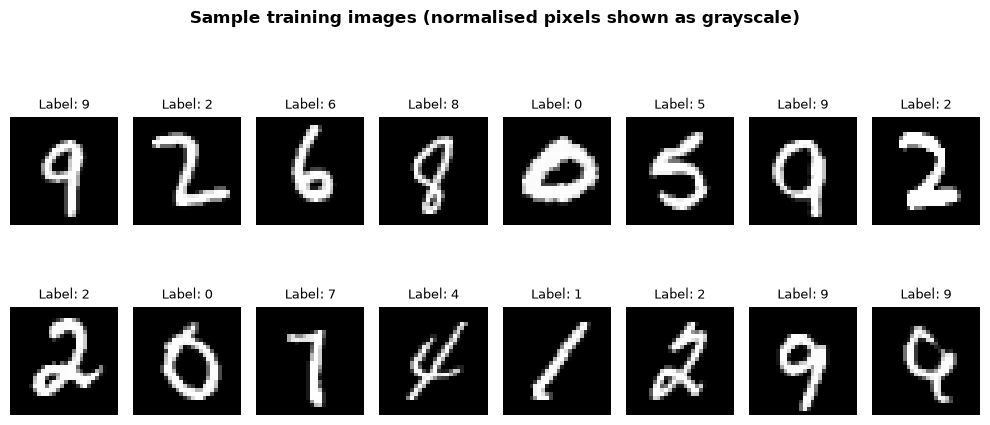

Image tensor shape : torch.Size([64, 1, 28, 28])
Label tensor shape : torch.Size([64])
Pixel range        : [-0.424, 2.821]


In [3]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 8, figsize=(10, 5))
fig.suptitle("Sample training images (normalised pixels shown as grayscale)",
             fontsize=12, fontweight='bold')

for i, ax in enumerate(axes.flat):
    img = images[i].squeeze().numpy()
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Label: {labels[i].item()}", fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

print(f"Image tensor shape : {images.shape}")   # (64, 1, 28, 28)
print(f"Label tensor shape : {labels.shape}")   # (64,)
print(f"Pixel range        : [{images.min():.3f}, {images.max():.3f}]")


## Shared Training Utilities

In [21]:
def train_one_epoch(model, loader, optimizer, criterion):
    """Run one full pass over the training set. Returns (avg_loss, accuracy)."""
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(X)
        loss   = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y)
        correct    += (logits.argmax(dim=1) == y).sum().item()
        n          += len(y)
    return total_loss / n, correct / n


def evaluate(model, loader, criterion):
    """Evaluate model on a dataloader. Returns (avg_loss, accuracy)."""
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            loss   = criterion(logits, y)
            total_loss += loss.item() * len(y)
            correct    += (logits.argmax(dim=1) == y).sum().item()
            n          += len(y)
    return total_loss / n, correct / n


def run_training(model, train_loader, val_loader, optimizer, criterion,
                 epochs=30, label=""):
    """Full training loop. Returns history dict."""
    history = {"train_loss": [], "val_loss": [],
               "train_acc":  [], "val_acc":  []}
    print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | "
          f"{'Val Loss':>9} | {'Val Acc':>8}")
    print("-" * 58)
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_loader, criterion)
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(va_acc)
        print(f"{epoch:>6} | {tr_loss:>10.4f} | {tr_acc:>9.4f} | "
        f"{va_loss:>9.4f} | {va_acc:>8.4f}")
    return history


def plot_history(histories: dict, title: str):
    """
    histories = {label: history_dict, ...}
    Plots loss and accuracy curves side-by-side.
    """
    colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    for i, (label, hist) in enumerate(histories.items()):
        c = colors[i % len(colors)]
        ep = range(1, len(hist['train_loss']) + 1)

        axes[0].plot(ep, hist['train_loss'], color=c, linestyle='-',
                     linewidth=2, label=f"{label} – Train")
        axes[0].plot(ep, hist['val_loss'],   color=c, linestyle='--',
                     linewidth=2, label=f"{label} – Val")

        axes[1].plot(ep, hist['train_acc'], color=c, linestyle='-',
                     linewidth=2, label=f"{label} – Train")
        axes[1].plot(ep, hist['val_acc'],   color=c, linestyle='--',
                     linewidth=2, label=f"{label} – Val")

    for ax, ylabel, ylbl in zip(axes,
                                 ['Loss', 'Accuracy'],
                                 ['Cross-Entropy Loss', 'Accuracy']):
        ax.set_xlabel('Epoch', fontsize=11)
        ax.set_ylabel(ylbl, fontsize=11)
        ax.set_title(ylabel, fontsize=12)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

print("Utility functions defined ✓")


Utility functions defined ✓


## Stage 2 — Baseline Model

### Strategy
The baseline model serves as a **reference architecture** to establish normal learning behaviour before intentionally inducing overfitting.

| Choice | Value | Effect |
|----------|----------|----------|
| Hidden layers | 128 → 64 | Sufficient capacity for MNIST without excessive complexity |
| Activation | ReLU | Introduces non-linearity and enables efficient gradient propagation |
| Optimiser | Adam, lr = 1e-3 | Fast and stable convergence |
| Weight decay | 0 | Pure baseline without regularisation |
| Data augmentation | None | Allows evaluation of natural model generalisation |
| Epochs | 7 | Enough training to reach convergence without prolonged fitting |

**Expected training signal**: both training and validation losses decrease steadily, training and validation accuracies remain close, and only a small generalisation gap appears — indicating effective learning with minimal overfitting.

In [22]:
class BaselineNet(nn.Module):
    """
    A reasonably-sized fully connected network — the 'normal' model.
    Small enough that it should generalize well without needing
    extra regularization. This is the reference point that OverfitNet
    is later derived from by scaling up capacity and removing safeguards.
    """
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 128), nn.ReLU(),
            nn.Linear(128, 64),  nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.network(x)


model_baseline = BaselineNet().to(device)
total_params = sum(p.numel() for p in model_baseline.parameters())
print(f"Architecture : BaselineNet (Normal Model)")
print(f"Parameters   : {total_params:,}")
print()
print(model_baseline)

Architecture : BaselineNet (Normal Model)
Parameters   : 109,386

BaselineNet(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [23]:
EPOCHS = 7
criterion = nn.CrossEntropyLoss()

In [24]:
model_baseline = BaselineNet().to(device)

total_params = sum(p.numel() for p in model_baseline.parameters())
print(total_params)

109386


In [25]:
optimizer_baseline = optim.Adam(model_baseline.parameters(), lr=1e-3)

print("=" * 60)
print("Stage 2 — Training BaselineNet (Normal Model)")
print("=" * 60)
history_baseline = run_training(
    model_baseline, train_loader, val_loader,
    optimizer_baseline, criterion,
    epochs=EPOCHS, label="BaselineNet"
)

Stage 2 — Training BaselineNet (Normal Model)
 Epoch | Train Loss | Train Acc |  Val Loss |  Val Acc
----------------------------------------------------------
     1 |     0.2973 |    0.9131 |    0.2178 |   0.9307
     2 |     0.1271 |    0.9608 |    0.1286 |   0.9604
     3 |     0.0891 |    0.9721 |    0.1225 |   0.9635
     4 |     0.0683 |    0.9780 |    0.1047 |   0.9685
     5 |     0.0557 |    0.9819 |    0.1048 |   0.9695
     6 |     0.0424 |    0.9860 |    0.0947 |   0.9727
     7 |     0.0364 |    0.9880 |    0.0921 |   0.9735


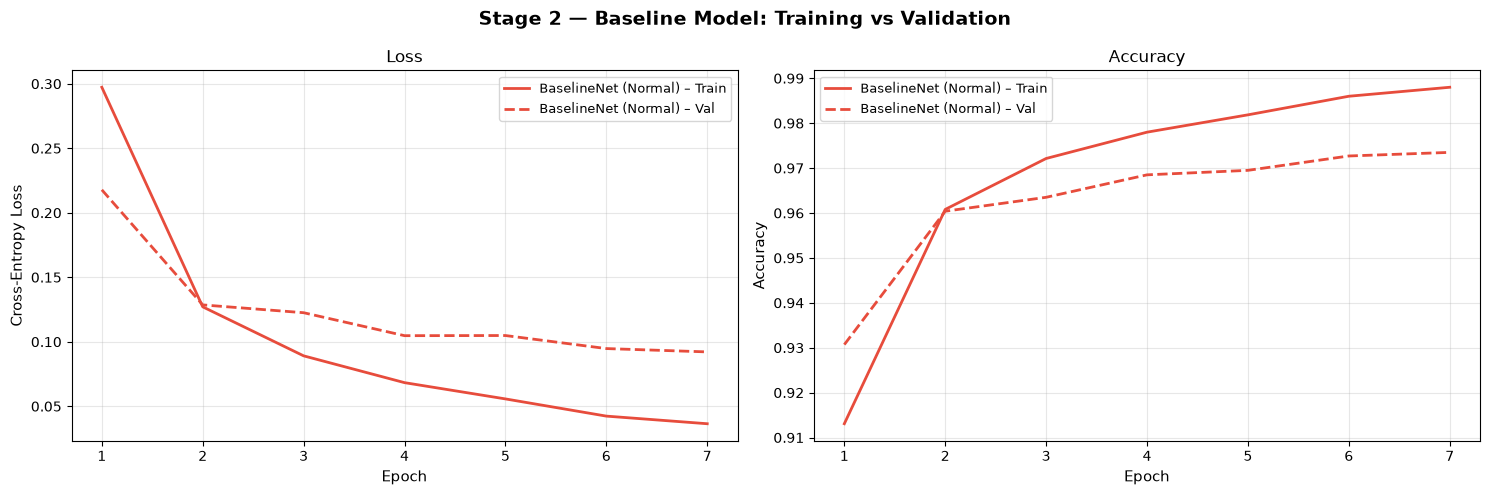

Final Train Accuracy : 0.9880
Final Val   Accuracy : 0.9735
Generalisation Gap   : 0.0145

This is a healthy, well-generalising model — train and validation
performance track closely, with no signs of severe overfitting.


In [26]:
plot_history(
    {"BaselineNet (Normal)": history_baseline},
    title="Stage 2 — Baseline Model: Training vs Validation"
)

final_train_acc = history_baseline['train_acc'][-1]
final_val_acc   = history_baseline['val_acc'][-1]
gap = final_train_acc - final_val_acc

print(f"Final Train Accuracy : {final_train_acc:.4f}")
print(f"Final Val   Accuracy : {final_val_acc:.4f}")
print(f"Generalisation Gap   : {gap:.4f}")
print()
print("This is a healthy, well-generalising model — train and validation")
print("performance track closely, with no signs of severe overfitting.")

## Stage 3 — Engineer Overfitting

### Strategy
To deliberately overfit we make the model **massively over-parameterised** relative to the dataset:

| Choice | Value | Effect |
|--------|-------|--------|
| Hidden layers | 4 × 2048 + 1 × 1024 | ~25 M parameters for only 50 k samples |
| Activation | ReLU (no Dropout) | No stochastic regularisation |
| Optimiser | Adam, lr = 1e-3 | Fast convergence → quick memorisation |
| Weight decay | 0 | No L2 penalty |
| Data augmentation | None | Model sees identical images every epoch |

**Expected training signal**: train loss → ~0, train accuracy → ~99 %+, while validation loss *rises* and val accuracy stagnates — the classic overfitting signature.

In [5]:
class OverfitNet(nn.Module):
    """
    Intentionally over-parameterised fully-connected network.
    ~25 M parameters — designed to memorise the training set.
    Architecture is IDENTICAL in Stage 4; only training procedure changes.
    """
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Flatten(),                          # 28*28 = 784

            nn.Linear(784,  2048), nn.ReLU(),
            nn.Linear(2048, 2048), nn.ReLU(),
            nn.Linear(2048, 2048), nn.ReLU(),
            nn.Linear(2048, 2048), nn.ReLU(),
            nn.Linear(2048, 1024), nn.ReLU(),

            nn.Linear(1024, 10)                   # 10 digit classes
        )

    def forward(self, x):
        return self.network(x)


model_overfit = OverfitNet().to(device)

total_params = sum(p.numel() for p in model_overfit.parameters())
print(f"Architecture : OverfitNet")
print(f"Parameters   : {total_params:,}")
print()
print(model_overfit)


Architecture : OverfitNet
Parameters   : 16,305,162

OverfitNet(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=2048, bias=True)
    (2): ReLU()
    (3): Linear(in_features=2048, out_features=2048, bias=True)
    (4): ReLU()
    (5): Linear(in_features=2048, out_features=2048, bias=True)
    (6): ReLU()
    (7): Linear(in_features=2048, out_features=2048, bias=True)
    (8): ReLU()
    (9): Linear(in_features=2048, out_features=1024, bias=True)
    (10): ReLU()
    (11): Linear(in_features=1024, out_features=10, bias=True)
  )
)


### Train the Overfitting Model

In [6]:
EPOCHS    = 50
criterion = nn.CrossEntropyLoss()

optimizer_overfit = optim.Adam(
    model_overfit.parameters(),
    lr=1e-3,
    weight_decay=0.0      # ← no regularisation
)

print("=" * 60)
print("Stage 3 — Training OverfitNet (no regularisation)")
print("=" * 60)
history_overfit = run_training(
    model_overfit, train_loader, val_loader,
    optimizer_overfit, criterion,
    epochs=EPOCHS, label="OverfitNet"
)


Stage 3 — Training OverfitNet (no regularisation)
 Epoch | Train Loss | Train Acc |  Val Loss |  Val Acc
----------------------------------------------------------
     1 |     0.3260 |    0.9100 |    0.2282 |   0.9405
     5 |     0.0730 |    0.9813 |    0.1313 |   0.9719
    10 |     0.0437 |    0.9883 |    0.1191 |   0.9772
    15 |     0.0365 |    0.9912 |    0.1219 |   0.9768
    20 |     0.0252 |    0.9945 |    0.1239 |   0.9782
    25 |     0.0220 |    0.9952 |    0.1626 |   0.9815
    30 |     0.0117 |    0.9973 |    0.1664 |   0.9819
    35 |     0.0141 |    0.9975 |    0.1922 |   0.9740
    40 |     0.0147 |    0.9972 |    0.4019 |   0.9819
    45 |     0.0080 |    0.9985 |    0.1614 |   0.9825
    50 |     0.0091 |    0.9982 |    0.2264 |   0.9832


### Visualise Overfitting

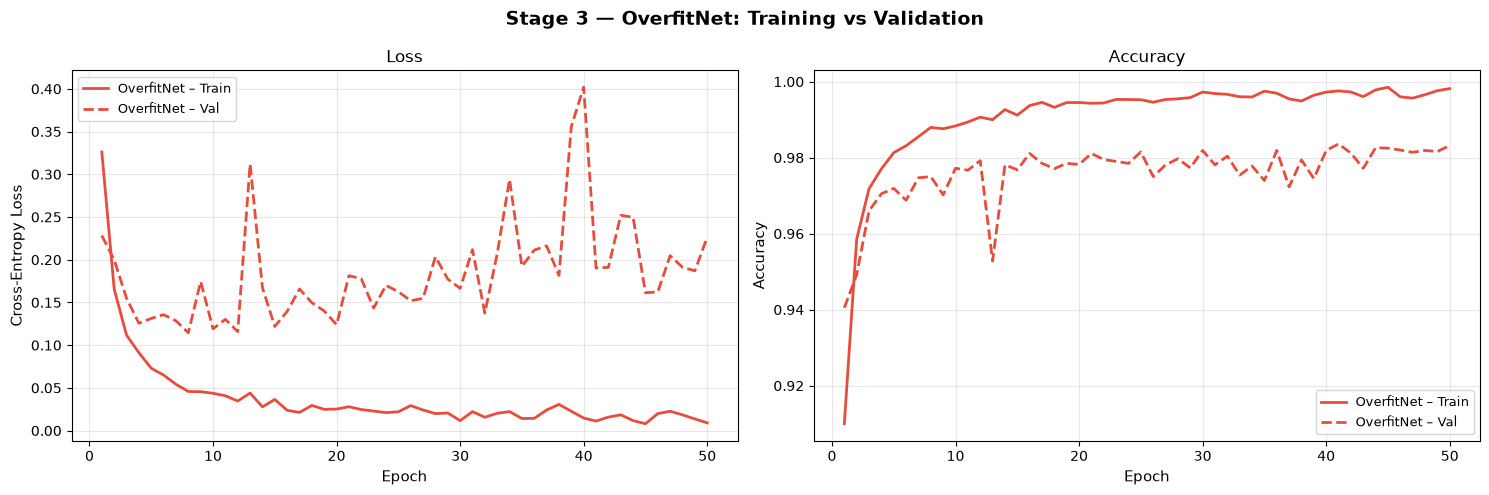

Final Train Accuracy : 0.9982 (99.82%)
Final Val   Accuracy : 0.9832  (98.32%)
Generalisation Gap   : 0.0150  (1.50 pp)

✅ Overfitting confirmed


In [7]:
plot_history(
    {"OverfitNet": history_overfit},
    title="Stage 3 — OverfitNet: Training vs Validation"
)

# Gap analysis
final_train_acc = history_overfit['train_acc'][-1]
final_val_acc   = history_overfit['val_acc'][-1]
gap             = final_train_acc - final_val_acc

print(f"Final Train Accuracy : {final_train_acc:.4f} ({final_train_acc*100:.2f}%)")
print(f"Final Val   Accuracy : {final_val_acc:.4f}  ({final_val_acc*100:.2f}%)")
print(f"Generalisation Gap   : {gap:.4f}  ({gap*100:.2f} pp)")
print()
if gap > 0.01:
    print("✅ Overfitting confirmed")
else:
    print("⚠️  Gap is small — consider training more epochs or increasing model size.")


## Stage 4 — Overcome Overfitting (Same Architecture)

### Allowed changes (no architecture modification)
The `OverfitNet` class definition is **unchanged**. We fix overfitting purely through:

| Technique | Implementation | Why it helps |
|-----------|---------------|--------------|
| **L2 Regularisation** | `weight_decay=1e-4` in Adam | Penalises large weights, discourages memorisation |
| **Data Augmentation** | Random rotation ±10°, Random translation ±10% | Each epoch the model sees a slightly different version of each image — effective dataset size increases |
| **Lower learning rate** | `lr = 5e-4` | More stable convergence, less overshoot into sharp minima |

> The train/val/test **split indices are identical** — we reuse `train_indices` from Stage 1.

In [8]:
# ── Augmented transform for Stage 4 train set ────────────────────────────────
augmented_transform = transforms.Compose([
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Reload training images with augmentation, keep EXACT same indices
full_train_aug = datasets.MNIST(root='./data', train=True,
                                 download=False, transform=augmented_transform)
train_dataset_aug   = Subset(full_train_aug, train_indices)   # same 50k indices
train_loader_aug    = DataLoader(train_dataset_aug, batch_size=BATCH_SIZE,
                                  shuffle=True, num_workers=2, pin_memory=True)

# Val and test loaders are UNCHANGED (no augmentation on evaluation sets)
print(f"Augmented train loader : {len(train_loader_aug)} batches of {BATCH_SIZE}")
print(f"Val loader             : {len(val_loader)} batches  (unchanged)")
print(f"Test loader            : {len(test_loader)} batches  (unchanged)")


Augmented train loader : 782 batches of 64
Val loader             : 157 batches  (unchanged)
Test loader            : 157 batches  (unchanged)


In [9]:
# ── Same architecture, new training procedure ─────────────────────────────────
model_fixed = OverfitNet().to(device)      # identical class — no change

optimizer_fixed = optim.Adam(
    model_fixed.parameters(),
    lr=5e-4,            # ← lower learning rate
    weight_decay=1e-4   # ← L2 regularisation
)

print("=" * 60)
print("Stage 4 — Training OverfitNet WITH regularisation")
print("=" * 60)
history_fixed = run_training(
    model_fixed, train_loader_aug, val_loader,
    optimizer_fixed, criterion,
    epochs=EPOCHS, label="FixedNet"
)


Stage 4 — Training OverfitNet WITH regularisation
 Epoch | Train Loss | Train Acc |  Val Loss |  Val Acc
----------------------------------------------------------
     1 |     0.4660 |    0.8536 |    0.1896 |   0.9428
     5 |     0.1415 |    0.9591 |    0.0981 |   0.9714
    10 |     0.1004 |    0.9703 |    0.0664 |   0.9803
    15 |     0.0856 |    0.9745 |    0.0741 |   0.9788
    20 |     0.0740 |    0.9768 |    0.0525 |   0.9842
    25 |     0.0707 |    0.9783 |    0.0611 |   0.9822
    30 |     0.0668 |    0.9793 |    0.0430 |   0.9866
    35 |     0.0615 |    0.9811 |    0.0419 |   0.9872
    40 |     0.0589 |    0.9821 |    0.0417 |   0.9880
    45 |     0.0583 |    0.9820 |    0.0481 |   0.9855
    50 |     0.0572 |    0.9814 |    0.0543 |   0.9829


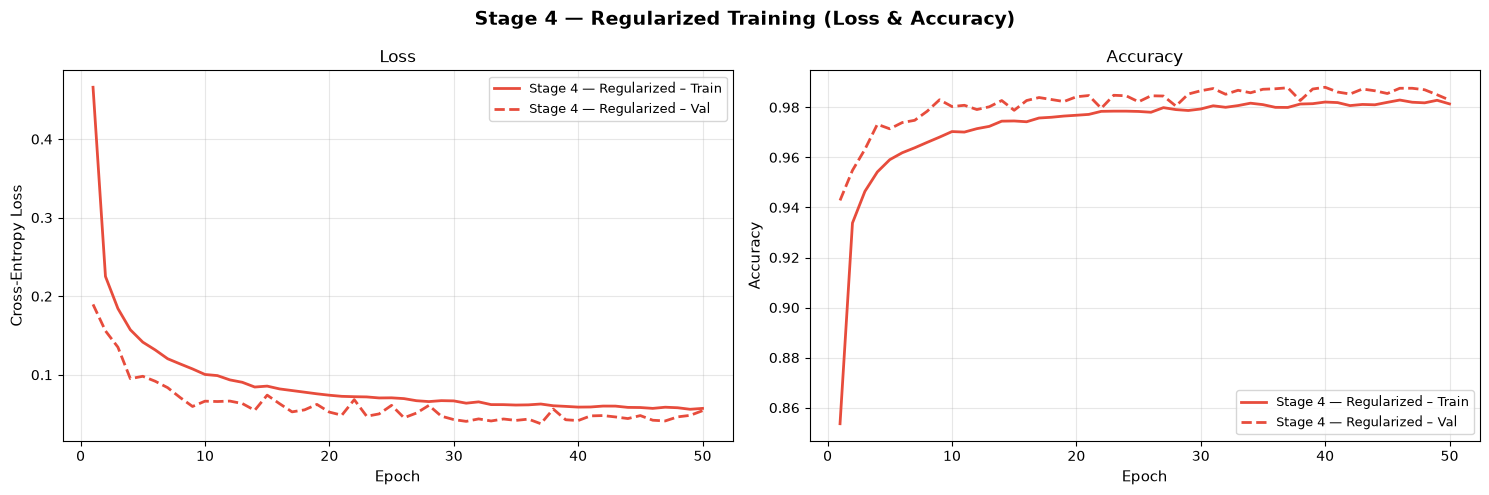

In [10]:
plot_history(
    {"Stage 4 — Regularized": history_fixed},
    title="Stage 4 — Regularized Training (Loss & Accuracy)"
)

## Comparison — Stage 3 vs Stage 4

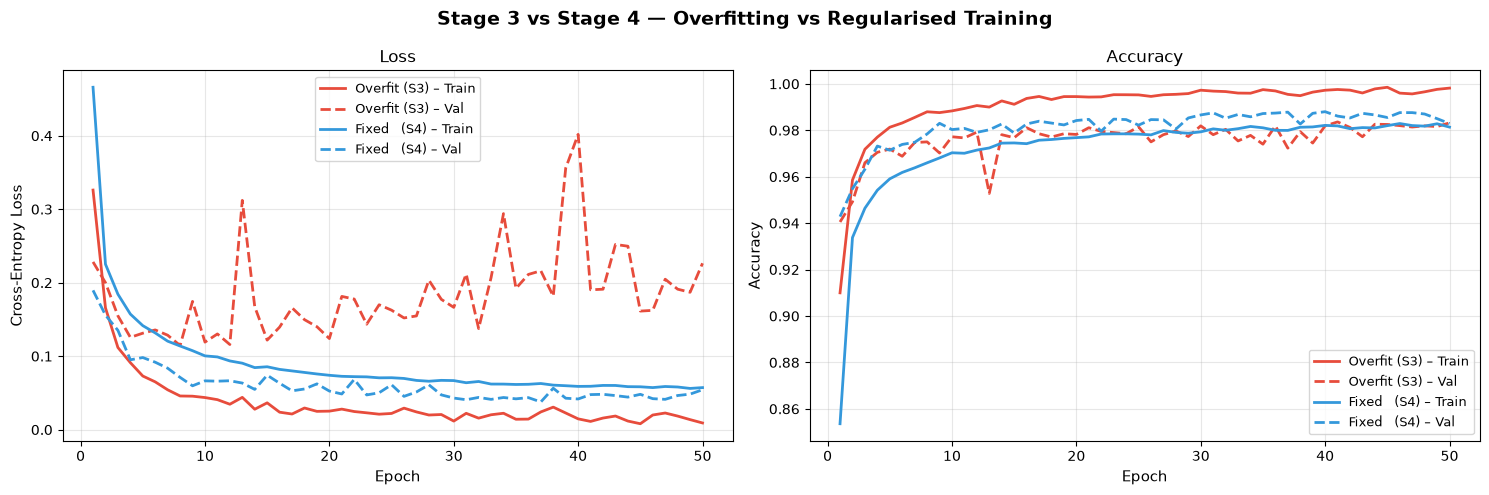

Metric                          Stage 3 (Overfit)  Stage 4 (Fixed)
------------------------------------------------------------------
Final Train Loss                           0.0091           0.0572
Final Val   Loss                           0.2264           0.0543
Final Train Acc                            0.9982           0.9814
Final Val   Acc                            0.9832           0.9829
Train-Val Acc Gap                          0.0150          -0.0015


In [11]:
plot_history(
    {
        "Overfit (S3)": history_overfit,
        "Fixed   (S4)": history_fixed,
    },
    title="Stage 3 vs Stage 4 — Overfitting vs Regularised Training"
)

# Side-by-side final metrics
print(f"{'Metric':<30} {'Stage 3 (Overfit)':>18} {'Stage 4 (Fixed)':>16}")
print("-" * 66)
metrics = [
    ("Final Train Loss",  history_overfit['train_loss'][-1], history_fixed['train_loss'][-1]),
    ("Final Val   Loss",  history_overfit['val_loss'][-1],   history_fixed['val_loss'][-1]),
    ("Final Train Acc",   history_overfit['train_acc'][-1],  history_fixed['train_acc'][-1]),
    ("Final Val   Acc",   history_overfit['val_acc'][-1],    history_fixed['val_acc'][-1]),
    ("Train-Val Acc Gap", history_overfit['train_acc'][-1] - history_overfit['val_acc'][-1],
                          history_fixed['train_acc'][-1]   - history_fixed['val_acc'][-1]),
]
for name, v1, v2 in metrics:
    print(f"{name:<30} {v1:>18.4f} {v2:>16.4f}")


### Loss curves — closer look

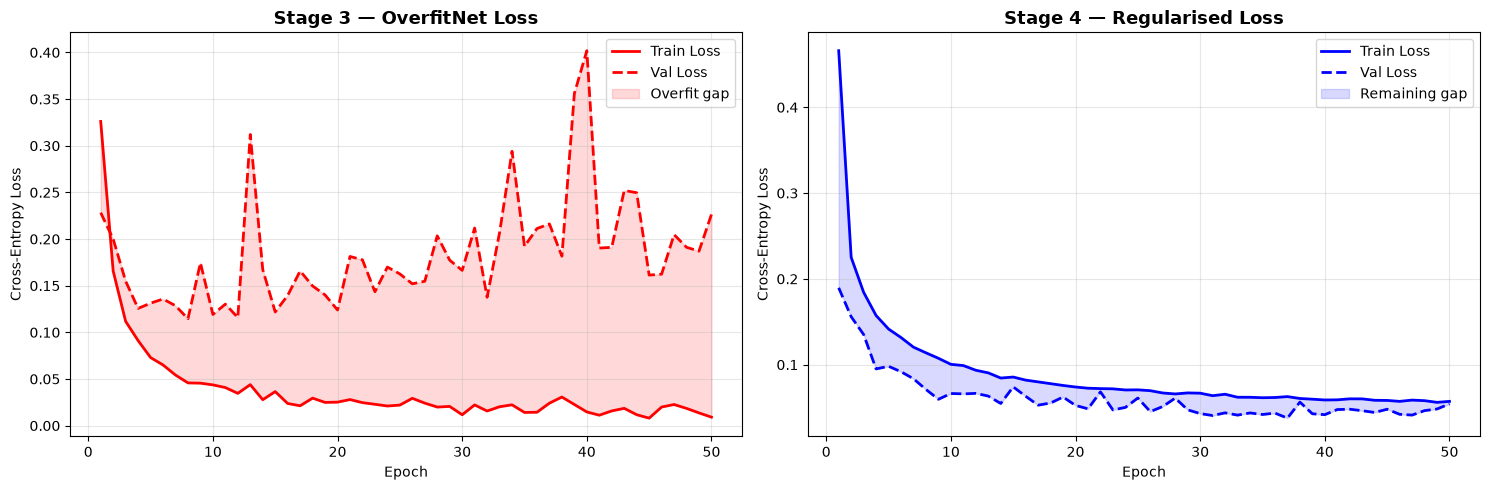

Saved: loss_curves.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ep = range(1, EPOCHS + 1)

# Stage 2
axes[0].plot(ep, history_overfit['train_loss'], 'r-',  lw=2, label='Train Loss')
axes[0].plot(ep, history_overfit['val_loss'],   'r--', lw=2, label='Val Loss')
axes[0].fill_between(ep,
    history_overfit['train_loss'], history_overfit['val_loss'],
    alpha=0.15, color='red', label='Overfit gap')
axes[0].set_title('Stage 3 — OverfitNet Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Stage 3
axes[1].plot(ep, history_fixed['train_loss'], 'b-',  lw=2, label='Train Loss')
axes[1].plot(ep, history_fixed['val_loss'],   'b--', lw=2, label='Val Loss')
axes[1].fill_between(ep,
    history_fixed['train_loss'], history_fixed['val_loss'],
    alpha=0.15, color='blue', label='Remaining gap')
axes[1].set_title('Stage 4 — Regularised Loss', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Cross-Entropy Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: loss_curves.png")


## Final Evaluation on Held-Out Test Set

The test set has **never** been seen during training or hyperparameter selection.

In [13]:
_, overfit_test_acc = evaluate(model_overfit, test_loader, criterion)
_, fixed_test_acc   = evaluate(model_fixed,   test_loader, criterion)

print("=" * 45)
print(f"{'Model':<25} {'Test Accuracy':>15}")
print("-" * 45)
print(f"{'Stage 3 — OverfitNet':<25} {overfit_test_acc:>14.4f}")
print(f"{'Stage 4 — Regularised':<25} {fixed_test_acc:>14.4f}")
print("=" * 45)
improvement = (fixed_test_acc - overfit_test_acc) * 100
print(f"\nRegularisation improved test accuracy by {improvement:.2f} percentage points.")


Model                       Test Accuracy
---------------------------------------------
Stage 3 — OverfitNet              0.9819
Stage 4 — Regularised             0.9856

Regularisation improved test accuracy by 0.37 percentage points.


### Per-Class Accuracy (Stage 4 — Regularised Model)

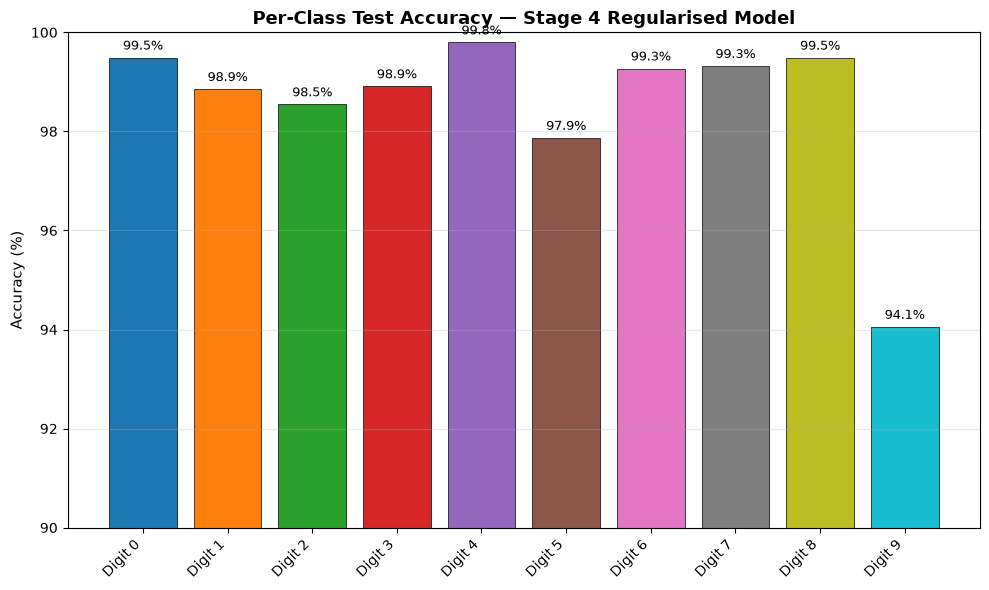


Per-class breakdown:
  Digit 0:  99.49%  █████████████████████████████████████████████████
  Digit 1:  98.85%  █████████████████████████████████████████████████
  Digit 2:  98.55%  █████████████████████████████████████████████████
  Digit 3:  98.91%  █████████████████████████████████████████████████
  Digit 4:  99.80%  █████████████████████████████████████████████████
  Digit 5:  97.87%  ████████████████████████████████████████████████
  Digit 6:  99.27%  █████████████████████████████████████████████████
  Digit 7:  99.32%  █████████████████████████████████████████████████
  Digit 8:  99.49%  █████████████████████████████████████████████████
  Digit 9:  94.05%  ███████████████████████████████████████████████


In [14]:
class_correct = torch.zeros(10)
class_total   = torch.zeros(10)

model_fixed.eval()
with torch.no_grad():
    for X, y in test_loader:
        X, y   = X.to(device), y.to(device)
        logits = model_fixed(X)
        preds  = logits.argmax(dim=1)
        for cls in range(10):
            mask = (y == cls)
            class_correct[cls] += (preds[mask] == y[mask]).sum().item()
            class_total[cls]   += mask.sum().item()

per_class_acc = (class_correct / class_total).numpy()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(range(10), per_class_acc * 100,
              color=plt.cm.tab10(np.linspace(0, 1, 10)), edgecolor='black', linewidth=0.5)
ax.set_xticks(range(10))
ax.set_xticklabels([f"Digit {i}" for i in range(10)], rotation=45, ha='right')
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_title('Per-Class Test Accuracy — Stage 4 Regularised Model', fontsize=13, fontweight='bold')
ax.set_ylim(90, 100)
ax.grid(True, axis='y', alpha=0.3)

for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            f'{acc*100:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPer-class breakdown:")
for i, acc in enumerate(per_class_acc):
    bar = '█' * int(acc * 50)
    print(f"  Digit {i}: {acc*100:6.2f}%  {bar}")


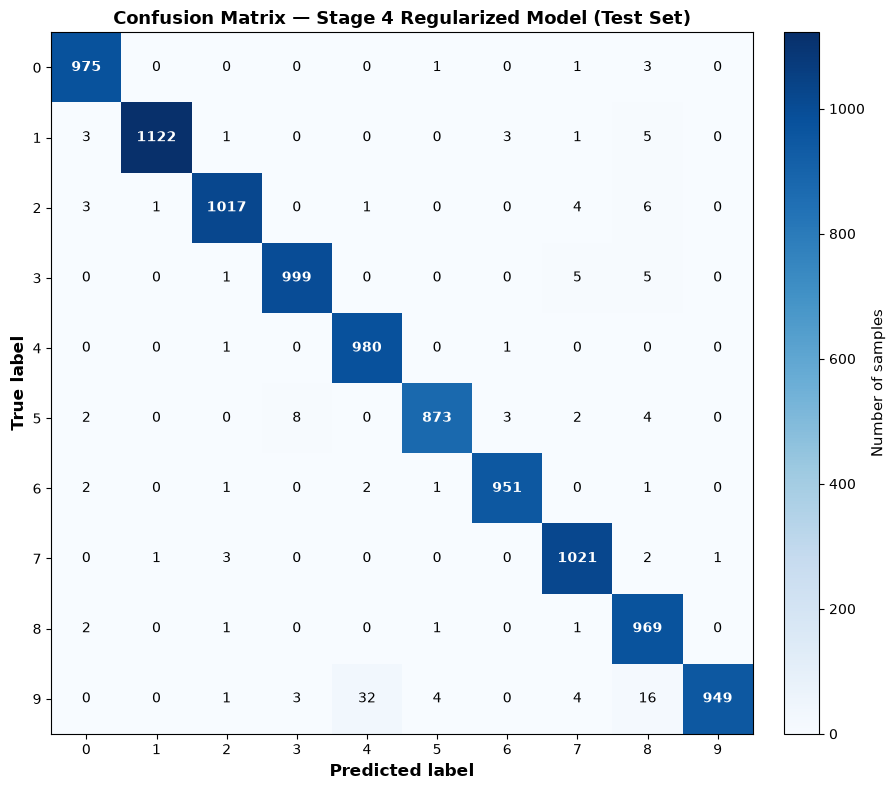

Top 5 most confused digit pairs (excluding correct predictions):

  True: 9  →  Predicted: 4   (32 times)
  True: 9  →  Predicted: 8   (16 times)
  True: 5  →  Predicted: 3   (8 times)
  True: 2  →  Predicted: 8   (6 times)
  True: 3  →  Predicted: 8   (5 times)


In [15]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

# ── Collect all predictions and true labels on the test set ─────────────────
model_fixed.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        logits = model_fixed(X)
        preds = logits.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# ── Compute confusion matrix ─────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(cm, cmap='Blues')

# Colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Number of samples', fontsize=11)

# Ticks and labels
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(range(10))
ax.set_yticklabels(range(10))
ax.set_xlabel('Predicted label', fontsize=12, fontweight='bold')
ax.set_ylabel('True label', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix — Stage 4 Regularized Model (Test Set)',
              fontsize=13, fontweight='bold')

# Annotate each cell with its count
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = "white" if cm[i, j] > thresh else "black"
        weight = "bold" if i == j else "normal"
        ax.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color=color, fontsize=10, fontweight=weight)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Print most confused digit pairs ──────────────────────────────────────────
print("Top 5 most confused digit pairs (excluding correct predictions):\n")
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

pairs = []
for i in range(10):
    for j in range(10):
        if i != j and cm_no_diag[i, j] > 0:
            pairs.append((cm_no_diag[i, j], i, j))

pairs.sort(reverse=True)
for count, true_digit, pred_digit in pairs[:5]:
    print(f"  True: {true_digit}  →  Predicted: {pred_digit}   ({count} times)")

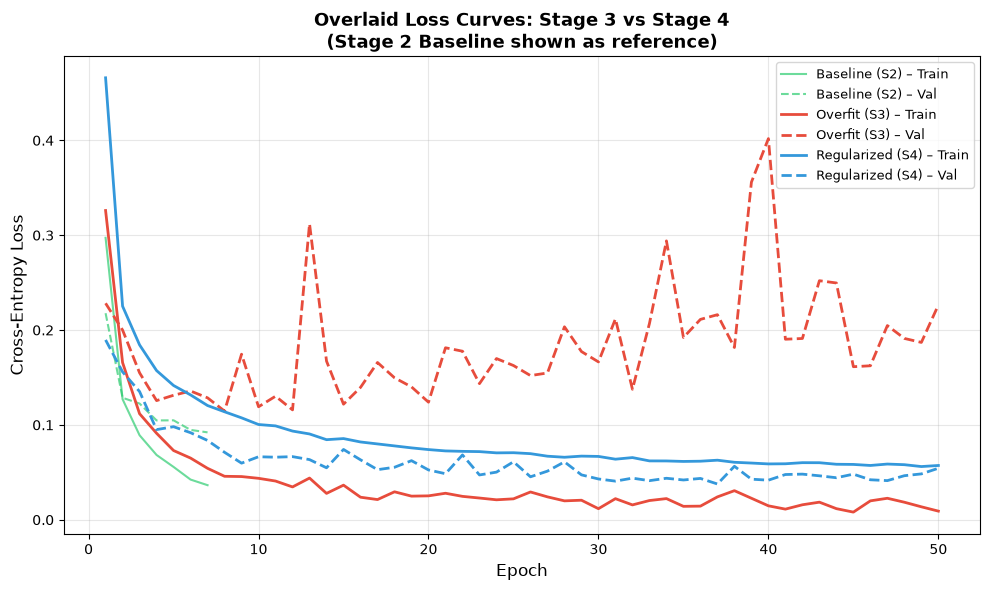

Saved: fig5_loss_comparison.png


In [29]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = {'baseline': '#2ecc71', 'overfit': '#e74c3c', 'fixed': '#3498db'}

# ── Stage 2 — Baseline (reference, dotted) ────────────────────────────────
ep_base = range(1, len(history_baseline['train_loss']) + 1)
ax.plot(ep_base, history_baseline['train_loss'], color=colors['baseline'],
         linestyle='-', linewidth=1.5, alpha=0.7, label='Baseline (S2) – Train')
ax.plot(ep_base, history_baseline['val_loss'], color=colors['baseline'],
         linestyle='--', linewidth=1.5, alpha=0.7, label='Baseline (S2) – Val')

# ── Stage 3 — Overfit ──────────────────────────────────────────────────────
ep_full = range(1, len(history_overfit['train_loss']) + 1)
ax.plot(ep_full, history_overfit['train_loss'], color=colors['overfit'],
         linestyle='-', linewidth=2, label='Overfit (S3) – Train')
ax.plot(ep_full, history_overfit['val_loss'], color=colors['overfit'],
         linestyle='--', linewidth=2, label='Overfit (S3) – Val')

# ── Stage 4 — Regularized ─────────────────────────────────────────────────
ax.plot(ep_full, history_fixed['train_loss'], color=colors['fixed'],
         linestyle='-', linewidth=2, label='Regularized (S4) – Train')
ax.plot(ep_full, history_fixed['val_loss'], color=colors['fixed'],
         linestyle='--', linewidth=2, label='Regularized (S4) – Val')

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Cross-Entropy Loss', fontsize=12)
ax.set_title('Overlaid Loss Curves: Stage 3 vs Stage 4\n(Stage 2 Baseline shown as reference)',
              fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='upper right', ncol=1)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig5_loss_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig5_loss_comparison.png")

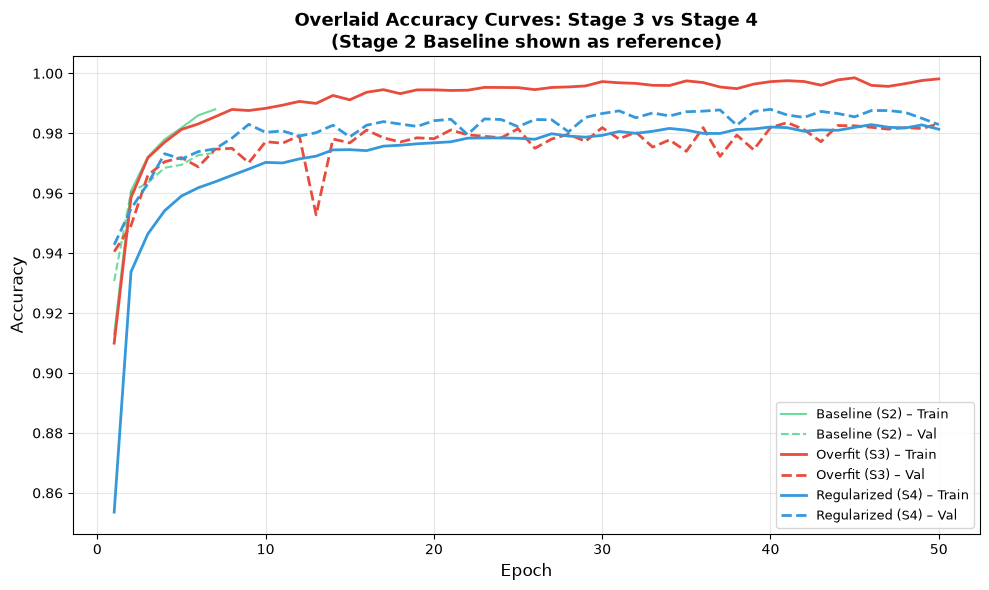

Saved: fig6_accuracy_comparison.png


In [30]:
fig, ax = plt.subplots(figsize=(10, 6))

# ── Stage 2 — Baseline (reference) ────────────────────────────────────────
ax.plot(ep_base, history_baseline['train_acc'], color=colors['baseline'],
         linestyle='-', linewidth=1.5, alpha=0.7, label='Baseline (S2) – Train')
ax.plot(ep_base, history_baseline['val_acc'], color=colors['baseline'],
         linestyle='--', linewidth=1.5, alpha=0.7, label='Baseline (S2) – Val')

# ── Stage 3 — Overfit ──────────────────────────────────────────────────────
ax.plot(ep_full, history_overfit['train_acc'], color=colors['overfit'],
         linestyle='-', linewidth=2, label='Overfit (S3) – Train')
ax.plot(ep_full, history_overfit['val_acc'], color=colors['overfit'],
         linestyle='--', linewidth=2, label='Overfit (S3) – Val')

# ── Stage 4 — Regularized ─────────────────────────────────────────────────
ax.plot(ep_full, history_fixed['train_acc'], color=colors['fixed'],
         linestyle='-', linewidth=2, label='Regularized (S4) – Train')
ax.plot(ep_full, history_fixed['val_acc'], color=colors['fixed'],
         linestyle='--', linewidth=2, label='Regularized (S4) – Val')

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Overlaid Accuracy Curves: Stage 3 vs Stage 4\n(Stage 2 Baseline shown as reference)',
              fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='lower right', ncol=1)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig6_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig6_accuracy_comparison.png")

## Summary

### What we demonstrated

| | Stage 2 (Overfit) | Stage 3 (Regularised) |
|--|--|--|
| **Architecture** | OverfitNet (~25M params) | **Same** OverfitNet |
| **Split** | 50k / 10k / 10k | **Same** split |
| **Optimiser** | Adam, lr=1e-3, wd=0 | Adam, lr=5e-4, wd=1e-4 |
| **Augmentation** | None | RandomRotation + RandomAffine |
| **Outcome** | High train acc, low val acc | Train ≈ Val acc |

### Key takeaways

1. **Overfitting** happens when a model has far more capacity than the data requires — it learns the training set *by heart* rather than generalising.
2. **You do not need to change the architecture** to fix overfitting. Regularisation techniques act directly on the training dynamics:
   - **L2 weight decay** discourages large weights → simpler, smoother decision boundaries
   - **Data augmentation** synthetically increases dataset diversity → the model can't simply memorise pixel patterns
   - **Lower learning rate** converges to flatter minima that generalise better
3. The validation set is your *early warning system* — always monitor the train/val gap during training.